<a href="https://colab.research.google.com/github/fernandinhaalmeida84/Tech_Challenge_Fase_2/blob/main/Notebook/01_Tratamento_e_AED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 1: Tratamento de Dados e Análise Exploratória (AED)**

**Problema de negócio:** dado o perfil cadastral de um solicitante de cartão de crédito, qual a chance de ele se tornar inadimplente? Para responder, usamos duas bases: o **cadastro** (quem é o cliente) e o **histórico de crédito** (como ele pagou, mês a mês).

**Objetivo deste notebook:** conhecer as duas bases, corrigir seus problemas de qualidade e entregar bases tratadas e confiáveis para os próximos notebooks. O target (Inad90 e Inad30) **não** é criado aqui: ele depende do histórico consolidado por cliente e é construído no Notebook 2.

**Roteiro e decisões**

| Etapa | O que fazemos | Por quê |
|---|---|---|
| 1. Estrutura do cadastro | Conferir tamanho, tipos e colunas | Saber com o que estamos trabalhando |
| 2. Duplicidades | Remover IDs repetidos com cadastros conflitantes; criar `PERFIL_ID` para perfis idênticos com IDs diferentes | Um mesmo ID não pode ter duas pessoas diferentes; perfis idênticos em treino e teste inflariam as métricas (*data leakage*) |
| 3. Ausentes | `OCCUPATION_TYPE` nulo vira `Unknown` | A ausência pode ser informação, e não perdemos 30% dos clientes |
| 4. Variáveis derivadas | `Idade`, `Anos_Trabalhados`, indicador `Desempregado ou aposentado` | `DAYS_*` em dias negativos é difícil de interpretar, e `365243` é código especial |
| 5. Outliers | Apenas diagnosticar, sem remover | Tratar antes do split treino/teste vazaria informação do teste |
| 6. Variáveis categóricas | Conhecer distribuição e categorias raras | Orienta o agrupamento e a codificação na modelagem |
| 7. Histórico de crédito | Qualidade, distribuição de `STATUS` e duração do histórico | Fundamenta a definição do target e revela o desbalanceamento |
| 8. Saída | Salvar as bases tratadas em `Data/Processed/` | O Notebook 2 parte destas bases, sem repetir a limpeza |

In [1]:
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

# Baixa o zip do GitHub (commit fixo) e extrai os CSVs em 'dados_extraidos', se ainda não existirem
URL_ZIP = ('https://github.com/fernandinhaalmeida84/Tech_Challenge_Fase_2/blob/'
           '1462573e4453793ed0c8e218b35ece6ce166caee/Data/Raw/BaseDadosFase2.zip?raw=true')
PASTA_DADOS = Path('dados_extraidos')

if not (PASTA_DADOS / 'application_record.csv').exists() or not (PASTA_DADOS / 'credit_record.csv').exists():
    PASTA_DADOS.mkdir(exist_ok=True)
    urllib.request.urlretrieve(URL_ZIP, 'BaseDadosFase2.zip')
    with zipfile.ZipFile('BaseDadosFase2.zip') as z:
        z.extractall(PASTA_DADOS)

df_cadastro = pd.read_csv(PASTA_DADOS / 'application_record.csv', sep=',')
df_credito = pd.read_csv(PASTA_DADOS / 'credit_record.csv', sep=',')
print('Cadastro:', df_cadastro.shape, '| Crédito:', df_credito.shape)

Cadastro: (438557, 18) | Crédito: (1048575, 3)


# **Parte A · Base cadastral (application_record.csv)**

## **1. Estrutura do arquivo**

O arquivo possui 18 colunas e 438.557 linhas. Porém, a quantidade de IDs únicos é de 438.510, ou seja, há IDs duplicados (tratados na seção 2).

Significado das colunas:

 - ID – Código do cliente
 - CODE_GENDER – Gênero
 - FLAG_OWN_CAR – Possui carro
 - FLAG_OWN_REALTY – Possui imóvel próprio
 - CNT_CHILDREN – Qtd de filhos
 - AMT_INCOME_TOTAL – Renda total declarada
 - NAME_INCOME_TYPE – Tipo/fonte de renda
 - NAME_EDUCATION_TYPE – Nível de escolaridade
 - NAME_FAMILY_STATUS – Estado civil
 - NAME_HOUSING_TYPE – Tipo de moradia
 - DAYS_BIRTH – Idade em dias (negativo: dias desde o nascimento até hoje)
 - DAYS_EMPLOYED – Tempo de serviço em dias (negativo: tempo de emprego atual)
 - FLAG_MOBIL – Possui celular
 - FLAG_WORK_PHONE – Telefone do trabalho
 - FLAG_PHONE – Telefone cadastrado
 - FLAG_EMAIL – E-mail cadastrado
 - OCCUPATION_TYPE – Profissão/ocupação
 - CNT_FAM_MEMBERS – Qtd de pessoas no núcleo familiar

In [2]:
df_cadastro.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [3]:
df_cadastro.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [4]:
print('Linhas  :', df_cadastro.shape[0])
print('IDs únicos:', df_cadastro['ID'].nunique())

Linhas  : 438557
IDs únicos: 438510


In [5]:
df_cadastro.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,438557.0,NaN,NaN,NaN,6022176.269842,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CODE_GENDER,438557,2,F,294440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,438557,2,N,275459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,438557,2,Y,304074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNT_CHILDREN,438557.0,NaN,NaN,NaN,0.42739,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,NaN,NaN,NaN,187524.28601,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
NAME_INCOME_TYPE,438557,5,Working,226104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_EDUCATION_TYPE,438557,5,Secondary / secondary special,301821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_FAMILY_STATUS,438557,5,Married,299828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_HOUSING_TYPE,438557,6,House / apartment,393831,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **2. Duplicidades**

Há dois tipos de repetição no cadastro, com tratamentos diferentes.

### **2.1 IDs repetidos (47 IDs, 94 linhas)**

Como o mesmo `ID` aparece duas vezes, é preciso saber se são cópias ou cadastros diferentes. Se fossem cópias, bastaria manter uma. Verificamos abaixo.

In [6]:
ids_repetidos = df_cadastro.loc[df_cadastro['ID'].duplicated(keep=False), 'ID'].unique()
linhas_repetidas = df_cadastro[df_cadastro['ID'].isin(ids_repetidos)].sort_values('ID')

colunas_atributos = [c for c in df_cadastro.columns if c != 'ID']
# para cada ID repetido, quantos atributos diferem entre as duas linhas?
n_atributos_diferentes = (linhas_repetidas.groupby('ID')[colunas_atributos]
                          .nunique(dropna=False).gt(1).sum(axis=1))

print(f'IDs repetidos: {len(ids_repetidos)} | linhas envolvidas: {len(linhas_repetidas)}')
print(f'Linhas totalmente idênticas na base: {df_cadastro.duplicated().sum()}')
print(f'IDs cujas duas linhas são idênticas nos atributos: {(n_atributos_diferentes == 0).sum()}')
print(f'Mediana de atributos diferentes entre as duas linhas do mesmo ID: {n_atributos_diferentes.median():.0f} de {len(colunas_atributos)}')
display(linhas_repetidas.head(4))

IDs repetidos: 47 | linhas envolvidas: 94
Linhas totalmente idênticas na base: 0
IDs cujas duas linhas são idênticas nos atributos: 0
Mediana de atributos diferentes entre as duas linhas do mesmo ID: 9 de 17


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
425023,7022197,F,N,Y,0,450000.0,Commercial associate,Higher education,Separated,House / apartment,-19813,-1799,1,0,0,1,NaN,1.0
426818,7022197,M,Y,Y,3,135000.0,Working,Secondary / secondary special,Married,House / apartment,-11945,-735,1,0,0,1,Laborers,5.0
431911,7022327,M,Y,Y,0,256500.0,Commercial associate,Higher education,Married,House / apartment,-21503,-1674,1,0,0,1,Core staff,2.0
431545,7022327,F,N,Y,0,135000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-14771,-5298,1,0,0,0,High skill tech staff,1.0


**Decisão:** nenhum dos 47 IDs tem linhas idênticas. Os dois cadastros do mesmo ID descrevem **pessoas diferentes** (gênero, renda, escolaridade etc. divergem), então não há como saber qual está correto, nem a qual deles pertence o histórico de crédito. Removemos **todas as linhas desses IDs** (94 linhas, 0,02% da base). O impacto é mínimo e evita atribuir o histórico de pagamento à pessoa errada.

In [7]:
n_antes = len(df_cadastro)
df_cadastro = df_cadastro[~df_cadastro['ID'].isin(ids_repetidos)].reset_index(drop=True)
print(f'Linhas: {n_antes:,} -> {len(df_cadastro):,} | removidas: {n_antes - len(df_cadastro)}')
assert df_cadastro['ID'].is_unique

Linhas: 438,557 -> 438,463 | removidas: 94


### **2.2 Perfis idênticos com IDs diferentes**

Com os IDs agora únicos, olhamos outro tipo de repetição: clientes com **todos os atributos cadastrais iguais**, mudando só o `ID`.

In [8]:
COLS_PERFIL = [c for c in df_cadastro.columns if c != 'ID']   # as 17 colunas originais, sem ID
df_cadastro['PERFIL_ID'] = df_cadastro.groupby(COLS_PERFIL, dropna=False).ngroup()

tamanho_perfil = df_cadastro['PERFIL_ID'].map(df_cadastro['PERFIL_ID'].value_counts())
n_perfis = df_cadastro['PERFIL_ID'].nunique()
print(f'Clientes: {len(df_cadastro):,} | Perfis cadastrais distintos: {n_perfis:,}')
print(f'Clientes que dividem o perfil com ao menos outro cliente: {(tamanho_perfil > 1).mean():.1%}')
print(f'Maior perfil repetido: {tamanho_perfil.max()} clientes com atributos idênticos')

Clientes: 438,463 | Perfis cadastrais distintos: 90,084
Clientes que dividem o perfil com ao menos outro cliente: 96.5%
Maior perfil repetido: 115 clientes com atributos idênticos


**Decisão:** apenas ~90 mil perfis distintos explicam os ~438 mil clientes, e **96,5% dos clientes dividem o perfil com outros**. Isso não é erro a corrigir, mas um risco para a modelagem: se um perfil cair no treino e uma cópia dele no teste, o modelo "decora" o perfil e as métricas ficam artificialmente boas (*data leakage*).

Por isso **não removemos** essas linhas e criamos o `PERFIL_ID`, que identifica o perfil. Ele será usado para **separar treino e teste por grupo**, garantindo que um mesmo perfil nunca apareça nos dois conjuntos.

## **3. Valores ausentes**

Tratamos valores ausentes para não gerar resultados equivocados nas análises.

In [9]:
ausentes = df_cadastro.isnull().sum()
display(ausentes[ausentes > 0].to_frame('ausentes').assign(percentual=lambda t: (t['ausentes'] / len(df_cadastro) * 100).round(2)))

,ausentes,percentual
OCCUPATION_TYPE,134177,30.6


Apenas `OCCUPATION_TYPE` tem ausentes: **134.177 registros (30,6%)**. Em vez de descartá-los, substituímos pela categoria **"Unknown"**. Motivos: (1) descartar 30% da base seria uma perda grande; (2) quem não declara ocupação pode ter comportamento próprio, e essa informação fica preservada como categoria.

In [10]:
df_cadastro['OCCUPATION_TYPE'] = df_cadastro['OCCUPATION_TYPE'].fillna('Unknown')
print('Ausentes restantes na base:', int(df_cadastro.isnull().sum().sum()))

Ausentes restantes na base: 0


## **4. Limpeza e variáveis derivadas**

`DAYS_BIRTH` e `DAYS_EMPLOYED` estão em dias e com valores negativos (contados para trás a partir de hoje), o que dificulta a interpretação. Criamos três variáveis:

* **`Idade`** (anos): convertemos os dias de nascimento em anos, dividindo por 365,25 (considera os anos bissextos).

In [11]:
df_cadastro['Idade'] = (df_cadastro['DAYS_BIRTH'] * -1) / 365.25

* **`Desempregado ou aposentado`**: em `DAYS_EMPLOYED` há o valor positivo **365243**, um código especial da base que não representa tempo de trabalho (equivaleria a ~1.000 anos). Ele marca quem não tem emprego atual. A variável recebe `True` quando `DAYS_EMPLOYED == 365243` e `False` nos demais casos. Conferimos a que tipo de renda esse código está associado:

In [12]:
df_cadastro['Desempregado ou aposentado'] = df_cadastro['DAYS_EMPLOYED'] == 365243
pct_codigo = df_cadastro['Desempregado ou aposentado'].mean()
print(f"Registros com o código 365243: {df_cadastro['Desempregado ou aposentado'].sum():,} ({pct_codigo:.1%})")
display(pd.crosstab(df_cadastro['Desempregado ou aposentado'], df_cadastro['NAME_INCOME_TYPE']))

Registros com o código 365243: 75,314 (17.2%)


NAME_INCOME_TYPE,Commercial associate,Pensioner,State servant,Student,Working
Desempregado ou aposentado,,,,,
False,100726,164,36183,17,226059
True,0,75314,0,0,0


O código aparece em **75.314 clientes (17,2%) e todos são `Pensioner`**, o que confirma a leitura "sem emprego atual / aposentado".

* **`Anos_Trabalhados`**: convertemos os dias em anos e invertemos o sinal para obter valores positivos. Para o código 365243 atribuímos **zero anos**, para que ele não seja tratado como um tempo de serviço real, o que distorceria média, desvio e correlações. Essa é uma convenção de tratamento: zero aqui significa "sem emprego atual", e não necessariamente "nunca trabalhou". O indicador `Desempregado ou aposentado` preserva essa distinção.

In [13]:
# 365243 é um código especial da base, não um tempo real de emprego
df_cadastro['Anos_Trabalhados'] = np.where(
    df_cadastro['DAYS_EMPLOYED'] == 365243,
    0,
    -df_cadastro['DAYS_EMPLOYED'] / 365.25
)

display(df_cadastro[['DAYS_EMPLOYED', 'Desempregado ou aposentado', 'Anos_Trabalhados']].head(10))

,DAYS_EMPLOYED,Desempregado ou aposentado,Anos_Trabalhados
0,-4542,False,12.435318
1,-4542,False,12.435318
2,-1134,False,3.104723
3,-3051,False,8.353183
4,-3051,False,8.353183
5,-3051,False,8.353183
6,-3051,False,8.353183
7,365243,True,0.000000
8,365243,True,0.000000
9,365243,True,0.000000


Conferimos abaixo as colunas criadas, o preenchimento com "Unknown" e as faixas de valores esperadas:

In [14]:
display(df_cadastro[['ID', 'OCCUPATION_TYPE', 'Idade', 'Desempregado ou aposentado', 'Anos_Trabalhados']].head())

assert df_cadastro['Idade'].between(18, 100).all()
assert (df_cadastro['Anos_Trabalhados'] >= 0).all()
assert df_cadastro['OCCUPATION_TYPE'].notna().all()
print('Checagens ok: idade entre 18 e 100 anos, anos trabalhados >= 0 e sem ausentes em OCCUPATION_TYPE.')

,ID,OCCUPATION_TYPE,Idade,Desempregado ou aposentado,Anos_Trabalhados
0,5008804,Unknown,32.867899,False,12.435318
1,5008805,Unknown,32.867899,False,12.435318
2,5008806,Security staff,58.792608,False,3.104723
3,5008808,Sales staff,52.320329,False,8.353183
4,5008809,Sales staff,52.320329,False,8.353183


Checagens ok: idade entre 18 e 100 anos, anos trabalhados >= 0 e sem ausentes em OCCUPATION_TYPE.


## **5. Identificação de outliers**

Analisamos cada variável numérica relevante com métricas estatísticas (limites do IQR) e gráficos (boxplot e histograma).

**Aqui apenas diagnosticamos.** Em crédito, renda muito alta ou família grande podem ser casos reais; e calcular limites com a base inteira, antes de separar treino e teste, faria o teste influenciar o tratamento (*data leakage*). A decisão está na conclusão desta seção.

*   **5.1 Renda Total**

A renda apresenta assimetria à direita, com concentração nas faixas mais baixas e rendas muito elevadas. Identificamos **19.100 registros** acima do limite superior de **R$ 380.250,00**, o que corresponde a **4,36%** da base. A mediana é R$ 161.100 e a média R$ 187.522; o máximo é R$ 6.750.000, uma renda isolada que puxa a média.

--- AMT_INCOME_TOTAL ---
Limite superior para outlier: R$ 380,250.00
Quantidade de registros acima do limite: 19100 (4.36%)
Maior renda registrada: R$ 6,750,000.00


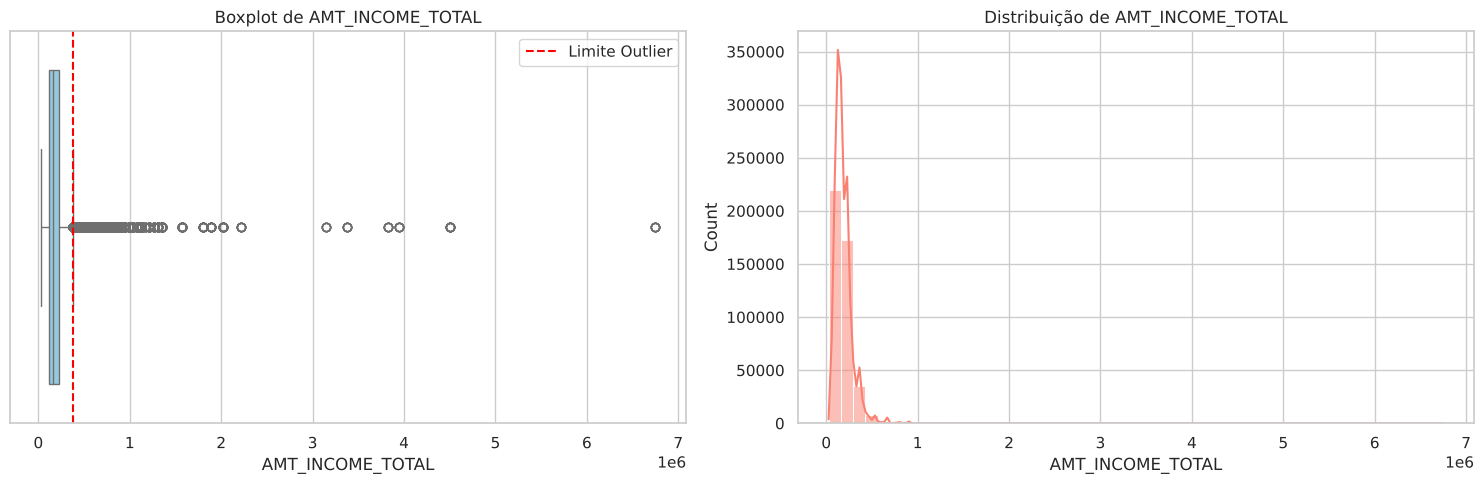

In [15]:
col = 'AMT_INCOME_TOTAL'
Q1 = df_cadastro[col].quantile(0.25)
Q3 = df_cadastro[col].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df_cadastro[df_cadastro[col] > limite_superior]
print(f"--- {col} ---")
print(f"Limite superior para outlier: R$ {limite_superior:,.2f}")
print(f"Quantidade de registros acima do limite: {outliers.shape[0]} ({outliers.shape[0]/df_cadastro.shape[0]*100:.2f}%)")
print(f"Maior renda registrada: R$ {df_cadastro[col].max():,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=df_cadastro[col], color='skyblue')
axes[0].set_title(f'Boxplot de {col}')
axes[0].axvline(limite_superior, color='red', linestyle='--', label='Limite Outlier')
axes[0].legend()

sns.histplot(ax=axes[1], x=df_cadastro[col], bins=50, kde=True, color='salmon')
axes[1].set_title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

*   **5.2 Tempo de serviço (`Anos_Trabalhados`)**

A distribuição tem assimetria à direita pronunciada. A grande maioria possui menos de 19,72 anos de trabalho. Há **5,01%** de outliers (21.968 registros), que chegam ao máximo de 48 anos. O pico em zero corresponde aos 17,2% sem emprego atual.

--- Anos_Trabalhados ---
Limite superior para outlier: 19.72 anos
Quantidade de registros acima do limite: 21968 (5.01%)
Máximo de anos trabalhados registrado: 48.00 anos


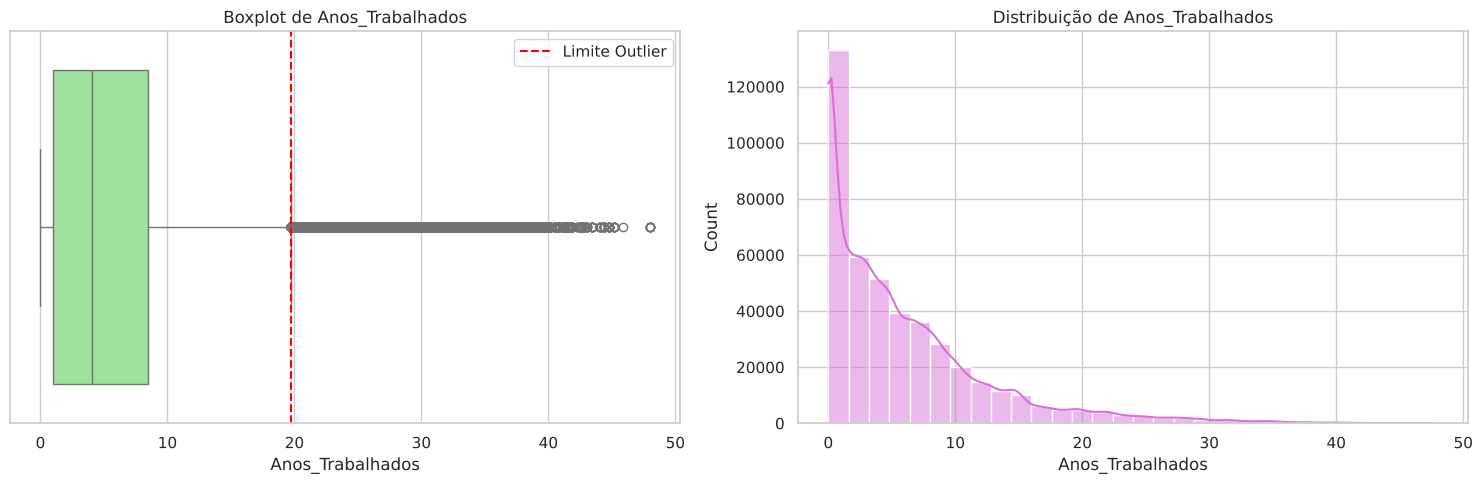

In [16]:
col = 'Anos_Trabalhados'
Q1 = df_cadastro[col].quantile(0.25)
Q3 = df_cadastro[col].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df_cadastro[df_cadastro[col] > limite_superior]
print(f"--- {col} ---")
print(f"Limite superior para outlier: {limite_superior:.2f} anos")
print(f"Quantidade de registros acima do limite: {outliers.shape[0]} ({outliers.shape[0]/df_cadastro.shape[0]*100:.2f}%)")
print(f"Máximo de anos trabalhados registrado: {df_cadastro[col].max():.2f} anos")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=df_cadastro[col], color='lightgreen')
axes[0].set_title(f'Boxplot de {col}')
axes[0].axvline(limite_superior, color='red', linestyle='--', label='Limite Outlier')
axes[0].legend()

sns.histplot(ax=axes[1], x=df_cadastro[col], bins=30, kde=True, color='orchid')
axes[1].set_title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

*   **5.3 Idade**

A variável apresenta distribuição bem comportada, **sem outliers estatísticos**. Todos os registros estão entre 20,5 e 69 anos, coerente com uma população adulta e ativa.

--- Idade ---
Limite inferior para outlier: 5.64 anos
Limite superior para outlier: 81.97 anos
Quantidade de registros fora dos limites: 0 (0.00%)
Idade mínima registrada: 20.50 anos
Idade máxima registrada: 69.00 anos


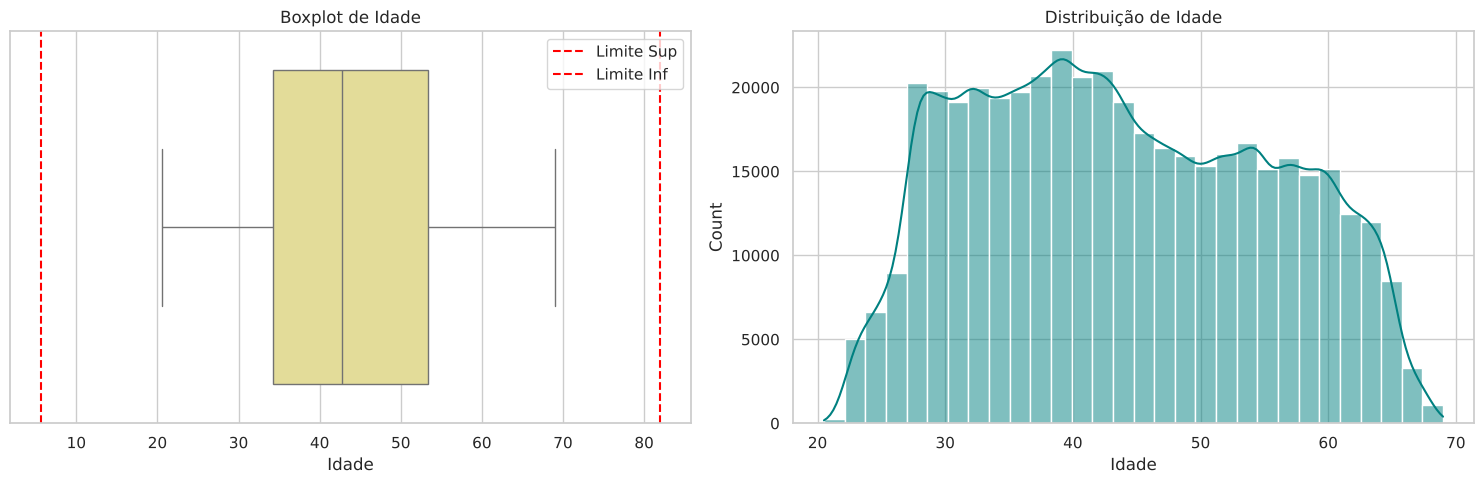

In [17]:
col = 'Idade'
Q1 = df_cadastro[col].quantile(0.25)
Q3 = df_cadastro[col].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_cadastro[(df_cadastro[col] < limite_inferior) | (df_cadastro[col] > limite_superior)]

print(f"--- {col} ---")
print(f"Limite inferior para outlier: {limite_inferior:.2f} anos")
print(f"Limite superior para outlier: {limite_superior:.2f} anos")
print(f"Quantidade de registros fora dos limites: {outliers.shape[0]} ({outliers.shape[0]/df_cadastro.shape[0]*100:.2f}%)")
print(f"Idade mínima registrada: {df_cadastro[col].min():.2f} anos")
print(f"Idade máxima registrada: {df_cadastro[col].max():.2f} anos")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=df_cadastro[col], color='khaki')
axes[0].set_title(f'Boxplot de {col}')
axes[0].axvline(limite_superior, color='red', linestyle='--', label='Limite Sup')
axes[0].axvline(limite_inferior, color='red', linestyle='--', label='Limite Inf')
axes[0].legend()

sns.histplot(ax=axes[1], x=df_cadastro[col], bins=30, kde=True, color='teal')
axes[1].set_title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

*   **5.4 Quantidade de membros da família**

A maioria das famílias tem entre 1 e 4 membros. Há **1,30%** de outliers (5.689 registros), alguns muito discrepantes, como 20 membros (pode ser erro de digitação/coleta ou família numerosa atípica). Apenas 609 registros têm mais de 5 membros.

--- CNT_FAM_MEMBERS ---
Limite inferior para outlier: 0.50
Limite superior para outlier: 4.50
Quantidade de registros fora dos limites: 5689 (1.30%)
Mínimo de membros familiar registrado: 1
Máximo de membros familiar registrado: 20


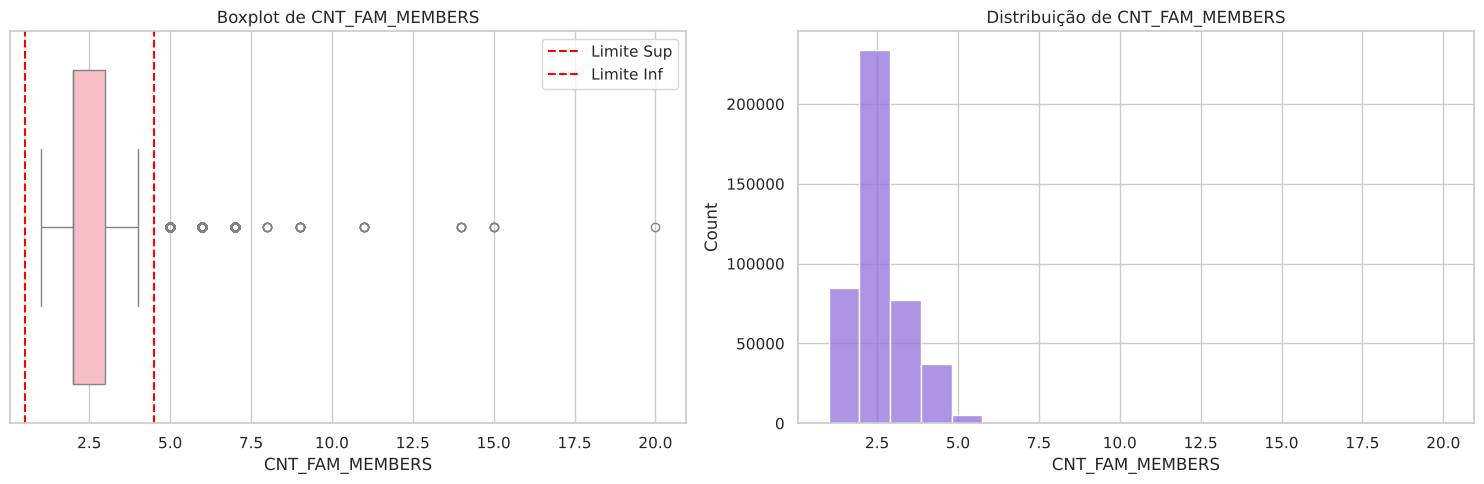

In [18]:
col = 'CNT_FAM_MEMBERS'
Q1 = df_cadastro[col].quantile(0.25)
Q3 = df_cadastro[col].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_cadastro[(df_cadastro[col] < limite_inferior) | (df_cadastro[col] > limite_superior)]

print(f"--- {col} ---")
print(f"Limite inferior para outlier: {limite_inferior:.2f}")
print(f"Limite superior para outlier: {limite_superior:.2f}")
print(f"Quantidade de registros fora dos limites: {outliers.shape[0]} ({outliers.shape[0]/df_cadastro.shape[0]*100:.2f}%)")
print(f"Mínimo de membros familiar registrado: {df_cadastro[col].min():.0f}")
print(f"Máximo de membros familiar registrado: {df_cadastro[col].max():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=df_cadastro[col], color='lightpink')
axes[0].set_title(f'Boxplot de {col}')
axes[0].axvline(limite_superior, color='red', linestyle='--', label='Limite Sup')
axes[0].axvline(limite_inferior, color='red', linestyle='--', label='Limite Inf')
axes[0].legend()

sns.histplot(ax=axes[1], x=df_cadastro[col], bins=20, kde=False, color='mediumpurple')
axes[1].set_title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

### **Conclusão da análise de outliers e decisão**

Há valores atípicos em três variáveis numéricas:

1. **Tempo de serviço (`Anos_Trabalhados`):** 5,01% acima do limite superior (19,72 anos).
2. **Tamanho familiar (`CNT_FAM_MEMBERS`):** 1,30% fora dos limites, com valores de até 20 membros.
3. **Renda (`AMT_INCOME_TOTAL`):** assimetria acentuada à direita, típica de variáveis financeiras (4,36% acima do limite).

`Idade` não tem outliers.

**Decisão metodológica**
* **Nenhum registro é removido nesta etapa**, para preservar informação (rendas altas e famílias grandes podem ser casos reais).
* O tratamento será feito na etapa de modelagem, **depois da divisão treino/teste**, com parâmetros calculados só no treino, para evitar *data leakage*:
  - `Anos_Trabalhados`: *winsorization* (capping) no limite superior do IQR do treino.
  - `CNT_FAM_MEMBERS`: truncamento fixo em 5 (valores maiores agrupados).
  - `AMT_INCOME_TOTAL`: transformação logarítmica `np.log1p()` para reduzir a assimetria e estabilizar a variância.

## **6. Variáveis categóricas e binárias**

Conhecemos a distribuição das categorias para decidir, na modelagem, quais agrupar ou descartar.

,0,1
% por valor,,
FLAG_MOBIL,0.0,100.0
FLAG_WORK_PHONE,79.4,20.6
FLAG_PHONE,71.2,28.8
FLAG_EMAIL,89.2,10.8


Colunas sem variação (um único valor): ['FLAG_MOBIL']


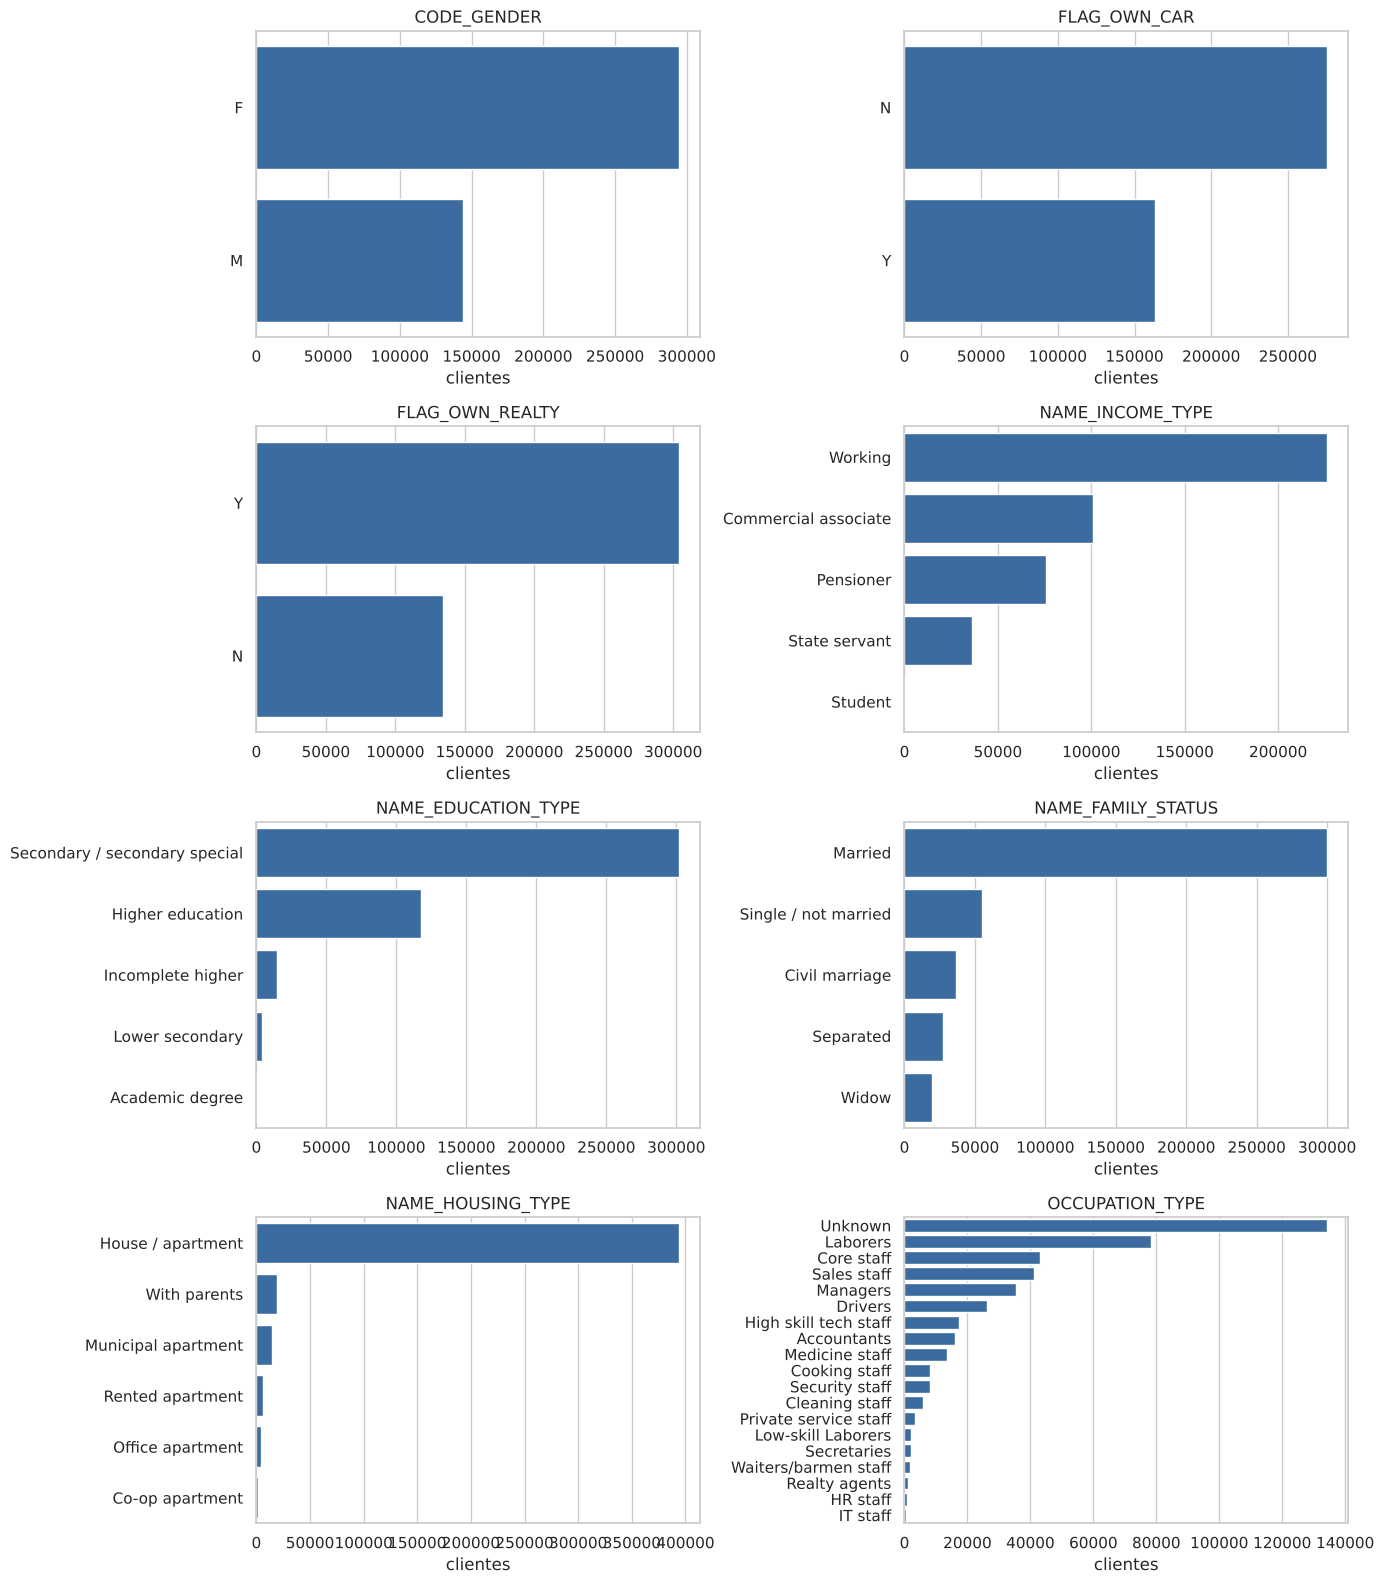

In [19]:
cols_cat = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
            'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, col in zip(axes.ravel(), cols_cat):
    contagem = df_cadastro[col].value_counts()
    sns.barplot(x=contagem.values, y=contagem.index, ax=ax, color='#2b6cb0')
    ax.set_title(col)
    ax.set_xlabel('clientes')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

cols_flag = ['FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
display(pd.DataFrame({c: df_cadastro[c].value_counts(normalize=True).mul(100).round(1) for c in cols_flag}).T
        .rename_axis('% por valor').fillna(0))
print('Colunas sem variação (um único valor):', [c for c in df_cadastro.columns if df_cadastro[c].nunique() == 1])

**Leitura**
* O perfil dominante é de mulheres (67%), casadas (68%), com ensino médio (69%), morando em casa/apartamento (90%) e com renda do tipo `Working` (52%). As categorias são **bastante desbalanceadas**.
* Há categorias muito raras (`Student`, com menos de 0,1% dos clientes, e `Academic degree`, com 0,1%). Com tão pouco suporte, elas serão agrupadas na modelagem.
* `OCCUPATION_TYPE` tem 19 categorias (18 ocupações mais `Unknown`), sendo `Unknown` a mais frequente (30,6%).
* **`FLAG_MOBIL` vale 1 para 100% dos clientes.** Sem variação, não discrimina nada e será descartada na modelagem.

# **Parte B · Base de histórico de crédito (credit_record.csv)**

## **7. Estrutura do arquivo**

O arquivo possui 3 colunas e 1.048.575 linhas, referentes a 45.985 clientes diferentes. Cada linha é um **cliente em um mês**.

* ID – Código do cliente
* MONTHS_BALANCE – Quantidade de meses em relação ao mês atual (0 = mês atual, -1 = mês anterior...)
* STATUS – Situação do pagamento do cliente naquele mês

In [20]:
df_credito.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [21]:
df_credito.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


In [22]:
print('Linhas:', df_credito.shape[0], '| Clientes distintos:', df_credito['ID'].nunique())

Linhas: 1048575 | Clientes distintos: 45985


In [23]:
df_credito.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,1048575.0,NaN,NaN,NaN,5068286.424673,46150.578505,5001711.0,5023644.0,5062104.0,5113856.0,5150487.0
MONTHS_BALANCE,1048575.0,NaN,NaN,NaN,-19.136998,14.023498,-60.0,-29.0,-17.0,-7.0,0.0
STATUS,1048575,8,C,442031,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **8. Análise da coluna STATUS**

A coluna indica a situação do pagamento do cliente em cada mês:
- C: Pago (dentro do prazo).
- X: Sem empréstimo ou transações ativos no mês.
- 0: 1-29 dias de atraso.
- 1: 30-59 dias de atraso.
- 2: 60-89 dias de atraso.
- 3: 90-119 dias de atraso.
- 4: 120-149 dias de atraso.
- 5: Mais de 150 dias de atraso (prejuízo).

Os códigos numéricos formam uma escala crescente de gravidade; `C` e `X` têm significados distintos (pago e sem crédito ativo, respectivamente).

In [24]:
ordem_status = ['C', 'X', '0', '1', '2', '3', '4', '5']

legenda_status = {
    'C': 'Pago (dentro do prazo)',
    'X': 'Sem transações ativas no mês',
    '0': 'Atraso de 1 a 29 dias',
    '1': 'Atraso de 30 a 59 dias',
    '2': 'Atraso de 60 a 89 dias',
    '3': 'Atraso de 90 a 119 dias',
    '4': 'Atraso de 120 a 149 dias',
    '5': 'Atraso de 150 dias ou mais (prejuízo)'
}

contagem = df_credito['STATUS'].value_counts()
proporcao = df_credito['STATUS'].value_counts(normalize=True) * 100

resumo_status = pd.DataFrame({
    'STATUS': ordem_status,
    'Count': contagem.reindex(ordem_status, fill_value=0).values,
    'Proportion': proporcao.reindex(ordem_status, fill_value=0).round(6).values,
    'Legenda': [legenda_status[s] for s in ordem_status],
    'Percentual (%)': proporcao.reindex(ordem_status, fill_value=0).round(2).values
})

# Centralizar os dados e os títulos, ocultando o índice numérico
display(
    resumo_status.style
    .hide(axis='index')
    .set_properties(**{'text-align': 'center', 'vertical-align': 'middle'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('vertical-align', 'middle')]},
        {'selector': 'td', 'props': [('padding', '8px')]}
    ])
    .format({'Proportion': '{:.6f}', 'Percentual (%)': '{:.2f}%'})
)

STATUS,Count,Proportion,Legenda,Percentual (%)
C,442031,42.155401,Pago (dentro do prazo),42.16%
X,209230,19.953747,Sem transações ativas no mês,19.95%
0,383120,36.537205,Atraso de 1 a 29 dias,36.54%
1,11090,1.057626,Atraso de 30 a 59 dias,1.06%
2,868,0.082779,Atraso de 60 a 89 dias,0.08%
3,320,0.030518,Atraso de 90 a 119 dias,0.03%
4,223,0.021267,Atraso de 120 a 149 dias,0.02%
5,1693,0.161457,Atraso de 150 dias ou mais (prejuízo),0.16%


Atenção: cada linha é um cliente em determinado mês, e o mesmo cliente aparece várias vezes. Portanto, os percentuais acima são a distribuição dos **status mensais**, e **não** a proporção de bons e maus pagadores.

Mesmo assim, a tabela já mostra algo central para o projeto: atraso leve (`0`, de 1 a 29 dias) é muito comum, mas atrasos graves são raros. Medimos isso abaixo.

In [25]:
pct_meses_30 = proporcao.reindex(['1', '2', '3', '4', '5']).sum()
pct_meses_90 = proporcao.reindex(['3', '4', '5']).sum()
print(f"Meses com atraso leve (status 0, 1-29 dias): {proporcao['0']:.2f}%")
print(f"Meses com atraso a partir de 30 dias (status 1 a 5): {pct_meses_30:.2f}%")
print(f"Meses com atraso a partir de 90 dias (status 3 a 5): {pct_meses_90:.2f}%")

Meses com atraso leve (status 0, 1-29 dias): 36.54%
Meses com atraso a partir de 30 dias (status 1 a 5): 1.35%
Meses com atraso a partir de 90 dias (status 3 a 5): 0.21%


**Leitura e implicações**
* **36,5% dos meses estão no status `0`.** Atrasar de 1 a 29 dias é comportamento comum, não sinal de risco. Por isso o status `0` **não** será considerado inadimplência.
* Atrasos a partir de 30 dias são **1,35%** dos meses e a partir de 90 dias, só **0,21%**. É esse corte que fundamenta os dois critérios de inadimplência do Notebook 2: **Inad30** (alternativo, atraso de 30 dias ou mais) e **Inad90** (principal, atraso de 90 dias ou mais).
* Como o evento é raro, o problema será **fortemente desbalanceado**. Por isso a avaliação usará AUC-PR, recall e F1, e não apenas acurácia.

## **9. Análise da coluna MONTHS_BALANCE**

Indica a distância em meses até o mês de referência dos dados: 0 é o mês mais recente e valores negativos (-1, -2, ...) são meses anteriores. Os valores variam de 0 a -60, ou seja, até 5 anos de histórico (61 meses).

In [26]:
valores_unicos = sorted(df_credito['MONTHS_BALANCE'].dropna().unique(), reverse=True)

print('Menor valor:', df_credito['MONTHS_BALANCE'].min())
print('Maior valor:', df_credito['MONTHS_BALANCE'].max())
print('Quantidade de valores únicos:', df_credito['MONTHS_BALANCE'].nunique())
print('Valores únicos:', [int(v) for v in valores_unicos])

Menor valor: -60
Maior valor: 0
Quantidade de valores únicos: 61
Valores únicos: [0, -1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31, -32, -33, -34, -35, -36, -37, -38, -39, -40, -41, -42, -43, -44, -45, -46, -47, -48, -49, -50, -51, -52, -53, -54, -55, -56, -57, -58, -59, -60]


## **10. Qualidade da base de crédito**

Um cliente aparecer em vários meses é esperado. Verificamos valores ausentes, linhas integralmente duplicadas e registros repetidos para a mesma combinação de ID e mês.

In [27]:
print('Dimensões da base:', df_credito.shape)

print('\nValores ausentes por coluna:')
display(df_credito.isna().sum())

print('\nIDs únicos:', df_credito['ID'].nunique())
print('Linhas integralmente duplicadas:', df_credito.duplicated().sum())
print('Duplicatas na combinação ID + mês:', df_credito.duplicated(subset=['ID', 'MONTHS_BALANCE']).sum())

Dimensões da base: (1048575, 3)

Valores ausentes por coluna:


ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64


IDs únicos: 45985
Linhas integralmente duplicadas: 0
Duplicatas na combinação ID + mês: 0


A base de crédito tem **1.048.575 registros, 3 colunas e 45.985 clientes**. Não há valores ausentes, linhas duplicadas nem duplicatas na combinação ID + mês: cada cliente tem no máximo um registro por mês. **Nenhum tratamento é necessário nesta base**, que segue inalterada para a etapa seguinte.

## **11. Duração do histórico por cliente**

Clientes com históricos mais longos têm mais oportunidades de apresentar atraso. Isso tende a inflar um target baseado em "ter atrasado em algum momento" e deve ser tratado como limitação do projeto.

In [28]:
historico_cliente = (
    df_credito.groupby('ID')
    .agg(
        MESES_OBSERVADOS=('MONTHS_BALANCE', 'nunique'),
        MES_MAIS_RECENTE=('MONTHS_BALANCE', 'max'),
        MES_MAIS_ANTIGO=('MONTHS_BALANCE', 'min')
    )
    .reset_index()
)

print('Resumo dos meses observados por cliente:')
display(historico_cliente['MESES_OBSERVADOS'].describe())

print('\nDistribuição da quantidade de meses (primeiras 20 categorias):')
display(historico_cliente['MESES_OBSERVADOS'].value_counts().sort_index().head(20))

Resumo dos meses observados por cliente:


count    45985.000000
mean        22.802544
std         15.492771
min          1.000000
25%         10.000000
50%         19.000000
75%         34.000000
max         61.000000
Name: MESES_OBSERVADOS, dtype: float64


Distribuição da quantidade de meses (primeiras 20 categorias):


MESES_OBSERVADOS
1      399
2     1088
3     1163
4     1339
5     1227
6     1439
7     1457
8     1531
9     1421
10    1300
11    1347
12    1356
13    1337
14    1172
15    1132
16    1115
17    1115
18    1112
19    1026
20     980
Name: count, dtype: int64

Os 45.985 clientes têm em média 22,8 meses observados (mediana 19), variando de 1 a 61 meses. Essa amplitude é grande: um cliente com 60 meses de histórico teve muito mais chances de atrasar do que um com 3 meses. Se não controlarmos isso, o modelo pode concluir, equivocadamente, que "histórico longo é sinal de risco". Por isso o tamanho do histórico será medido no Notebook 2 e **não poderá ser usado como variável preditora**: ele só é conhecido depois da aprovação.

## **12. Sobreposição entre as bases**

O modelo só pode aprender com clientes que têm **cadastro e histórico de crédito**. Medimos quantos são.

In [29]:
ids_cadastro, ids_credito = set(df_cadastro['ID']), set(df_credito['ID'])

sobreposicao = pd.Series({
    'Só no cadastro (sem histórico)': len(ids_cadastro - ids_credito),
    'Só no crédito (sem cadastro)': len(ids_credito - ids_cadastro),
    'Nas duas bases (utilizáveis na modelagem)': len(ids_cadastro & ids_credito)
}).to_frame('clientes')
sobreposicao['% do cadastro'] = (sobreposicao['clientes'] / len(ids_cadastro) * 100).round(1)
display(sobreposicao)

,clientes,% do cadastro
Só no cadastro (sem histórico),402006,91.7
Só no crédito (sem cadastro),9528,2.2
Nas duas bases (utilizáveis na modelagem),36457,8.3


Apenas **36.457 clientes (8,3% do cadastro)** aparecem nas duas bases e poderão ser usados na modelagem. Os demais não têm resposta observada (não sabemos se pagariam), então ficam de fora. Isso é uma **limitação de viés de seleção**: o modelo aprende só com quem já teve crédito aprovado e, por isso, pode não representar todos os solicitantes. Será registrada nas conclusões do projeto.

# **13. Síntese e entrega para o próximo notebook**

**Base cadastral (`application_record.csv`)**
- 438.557 linhas, 18 colunas originais e 438.510 IDs distintos.
- **47 IDs repetidos descreviam pessoas diferentes**: as 94 linhas foram removidas. A base tratada tem **438.463 clientes únicos**.
- 96,5% dos clientes dividem o perfil cadastral com outros (apenas ~90 mil perfis distintos). Criamos o `PERFIL_ID` para separar treino e teste por grupo e evitar *data leakage*.
- `OCCUPATION_TYPE` ausente (30,6%) virou "Unknown".
- O código 365243 (17,2%, todos aposentados) virou o indicador `Desempregado ou aposentado`, com `Anos_Trabalhados = 0`.
- Criadas `Idade` e `Anos_Trabalhados`.
- Outliers em `Anos_Trabalhados`, `CNT_FAM_MEMBERS` e renda foram diagnosticados e **serão tratados na modelagem, após o split**.
- `FLAG_MOBIL` é constante e será descartada.

**Base de crédito (`credit_record.csv`)**
- Sem ausentes nem duplicatas; segue sem alterações.
- Atraso leve (status 0) é comum (36,5% dos meses), enquanto atraso a partir de 30 dias é 1,35% e a partir de 90 dias é 0,21%: o problema é **fortemente desbalanceado**.
- A duração do histórico varia de 1 a 61 meses e pode enviesar o target; ela não pode ser variável do modelo.
- Só 36.457 clientes têm cadastro e histórico (viés de seleção).

**Próximo passo (Notebook 2):** consolidar o histórico por cliente, criar os targets **Inad90** (principal) e **Inad30** (alternativo), juntar com o cadastro tratado e analisar o perfil de bons e maus pagadores.

## **14. Salvando as bases tratadas**

Salvamos as duas bases em `Data/Processed/` (formato CSV compactado, que não exige bibliotecas extras). Elas são a **entrada do Notebook 2**, que não precisa repetir a limpeza. Os arquivos devem ser versionados no GitHub em `Data/Processed/`.

In [30]:
PROCESSED_DIR = Path('Data/Processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

ARQ_APP = PROCESSED_DIR / 'application_record_tratado.csv.gz'
ARQ_CRED = PROCESSED_DIR / 'credit_record_tratado.csv.gz'

df_cadastro.to_csv(ARQ_APP, index=False, compression='gzip')
df_credito.to_csv(ARQ_CRED, index=False, compression='gzip')

# Conferência: reler os arquivos salvos e comparar com o que está na memória
chk_app = pd.read_csv(ARQ_APP)
chk_cred = pd.read_csv(ARQ_CRED)
assert chk_app.shape == df_cadastro.shape and chk_cred.shape == df_credito.shape
assert (chk_app['ID'].values == df_cadastro['ID'].values).all()
assert (chk_app['PERFIL_ID'].values == df_cadastro['PERFIL_ID'].values).all()
assert chk_cred['STATUS'].astype(str).equals(df_credito['STATUS'].astype(str))

print(f'Base de cadastros salva em: {ARQ_APP} | {chk_app.shape[0]:,} linhas x {chk_app.shape[1]} colunas | {ARQ_APP.stat().st_size / 1e6:.1f} MB')
print(f'Base de créditos salva em : {ARQ_CRED} | {chk_cred.shape[0]:,} linhas x {chk_cred.shape[1]} colunas | {ARQ_CRED.stat().st_size / 1e6:.1f} MB')
print('Colunas do cadastro tratado:', list(chk_app.columns))

# No Colab, baixa os arquivos para subir manualmente no GitHub (Data/Processed/)
try:
    from google.colab import files
    files.download(str(ARQ_APP))
    files.download(str(ARQ_CRED))
except ImportError:
    pass

Base de cadastros salva em: Data/Processed/application_record_tratado.csv.gz | 438,463 linhas x 22 colunas | 5.2 MB
Base de créditos salva em : Data/Processed/credit_record_tratado.csv.gz | 1,048,575 linhas x 3 colunas | 2.8 MB
Colunas do cadastro tratado: ['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'PERFIL_ID', 'Idade', 'Desempregado ou aposentado', 'Anos_Trabalhados']
